# CV Baseline: Contour-based Stamp Detection

**Цель:** Проверить работоспособность contour-based эвристики для детекции штампов.

**Метод:**
1. Adaptive thresholding → бинаризация
2. findContours → поиск контуров
3. Union box: родительский контур + children
4. Проверка aspect ratio vs ожидаемый (~3.5:1)

**Данные:** 49 реальных изображений (без синтетики)

**Почему без синтетики:** CV baseline не улучшается от синтетических данных — эвристика работает на реальных контурах.


In [1]:
import sys
sys.path.insert(0, "../src")

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

from data.loader import load_image_and_labels

DATA_DIR = Path("../data")
IMAGE_DIR = DATA_DIR / "images" / "test"
LABEL_DIR = DATA_DIR / "labels" / "test"

# Параметры из анализа данных
EXPECTED_ASPECT_RATIO = 3.55  # среднее из EDA
AR_TOLERANCE = 0.25
MIN_WIDTH_PX = 100
MIN_HEIGHT_PX = 30

print("Настройка завершена")

Настройка завершена


## IoU Function

Реализация Intersection over Union для оценки качества детекции.

In [2]:
def compute_iou(bbox1, bbox2):
    """
    bbox = (x, y, w, h)
    """
    x1, y1, w1, h1 = bbox1
    x2, y2, w2, h2 = bbox2
    
    xi1 = max(x1, x2)
    yi1 = max(y1, y2)
    xi2 = min(x1 + w1, x2 + w2)
    yi2 = min(y1 + h1, y2 + h2)
    
    inter_w = max(0, xi2 - xi1)
    inter_h = max(0, yi2 - yi1)
    inter_area = inter_w * inter_h
    
    union_area = w1 * h1 + w2 * h2 - inter_area
    
    if union_area == 0:
        return 0.0
    
    return inter_area / union_area

def bbox_to_pixel(label, img_w, img_h):
    _, cx, cy, bw, bh = label
    x = int((cx - bw / 2) * img_w)
    y = int((cy - bh / 2) * img_h)
    w = int(bw * img_w)
    h = int(bh * img_h)
    return (x, y, w, h)

## Contour Detection Functions

Адаптировано из localization.py:
- Adaptive threshold
- Find contours hierarchy
- Union box из children
- Aspect ratio check

In [3]:
def compute_iou(bbox1, bbox2):
    x1, y1, w1, h1 = bbox1
    x2, y2, w2, h2 = bbox2
    xi1, yi1 = max(x1, x2), max(y1, y2)
    xi2, yi2 = min(x1+w1, x2+w2), min(y1+h1, y2+h2)
    inter = max(0, xi2-xi1) * max(0, yi2-yi1)
    union = w1*h1 + w2*h2 - inter
    return inter/union if union > 0 else 0.0

def bbox_to_pixel(label, img_w, img_h):
    _, cx, cy, bw, bh = label
    x = int((cx - bw/2) * img_w)
    y = int((cy - bh/2) * img_h)
    w = int(bw * img_w)
    h = int(bh * img_h)
    return (x, y, w, h)

def detect_dpi(w, h):
    # DPI detection from image dimensions
    A4_SIZES = {(1754, 2480): 200, (2480, 3508): 300, (3508, 4961): 400}
    for (ew, eh), dpi in A4_SIZES.items():
        if abs(w-ew) < 50 and abs(h-eh) < 50:
            return dpi
    return int(w / 8.27)

def extract_roi(image, roi_type, dpi=None):
    h, w = image.shape[:2]
    # ROI ratios from preprocessing.py
    w_ratio, h_ratio = 0.3, 0.25
    half_w, half_h = int(w*w_ratio), int(h*h_ratio)
    
    if roi_type == 'bottom_right':
        x, y, roi_w, roi_h = w-half_w, h-half_h, half_w, half_h
    elif roi_type == 'bottom':
        x, y, roi_w, roi_h = 0, h-half_h, w, half_h
    elif roi_type == 'right':
        x, y, roi_w, roi_h = w-half_w, 0, half_w, h
    else:  # full_page
        x, y, roi_w, roi_h = 0, 0, w, h
    
    return image[y:y+roi_h, x:x+roi_w], (x, y, roi_w, roi_h)

def find_stamp_contours(roi, expected_ar, ar_tolerance, min_w, min_h):
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY) if len(roi.shape) == 3 else roi
    denoised = cv2.GaussianBlur(gray, (3, 3), 0)
    
    # CLAHE for better contrast
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(denoised)
    
    block_size = 11
    binary = cv2.adaptiveThreshold(
        enhanced, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        block_size, 5
    )
    
    contours, hierarchy = cv2.findContours(binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    if hierarchy is None or len(contours) == 0:
        return [], (0, 0, 0, 0)
    
    hierarchy = hierarchy[0]
    memo = {}
    candidates = []
    
    def get_depth(idx, memo):
        if idx not in memo:
            parent = hierarchy[idx][3]
            memo[idx] = 0 if parent == -1 else 1 + get_depth(parent, memo)
        return memo[idx]
    
    for i, contour in enumerate(contours):
        if get_depth(i, memo) == 0:
            first_child = hierarchy[i][2]
            if first_child != -1:
                min_x, min_y = float('inf'), float('inf')
                max_x, max_y = float('-inf'), float('-inf')
                child_count = 0
                j = first_child
                while j != -1:
                    if get_depth(j, memo) == 1:
                        cx, cy, cw, ch = cv2.boundingRect(contours[j])
                        min_x, min_y = min(min_x, cx), min(min_y, cy)
                        max_x, max_y = max(max_x, cx+cw), max(max_y, cy+ch)
                        child_count += 1
                    j = hierarchy[j][0]
                if child_count > 1:
                    union_w, union_h = max_x-min_x, max_y-min_y
                    if union_w > min_w and union_h > min_h:
                        ar = union_w/union_h if union_h > 0 else 0
                        ratio_diff = abs(ar-expected_ar)/expected_ar
                        if ratio_diff <= ar_tolerance:
                            candidates.append({
                                'bbox': (min_x, min_y, union_w, union_h),
                                'ar': ar,
                                'conf': max(0.0, 1.0-ratio_diff/ar_tolerance)
                            })
    
    candidates.sort(key=lambda c: (c['conf'], c['bbox'][2]*c['bbox'][3]), reverse=True)
    return candidates, (0, 0, 0, 0)

def detect_stamp(image, expected_ar=3.55, ar_tolerance=0.25):
    h, w = image.shape[:2]
    
    # Detect orientation for ROI
    if h > w:
        roi_type = 'right' if h/w > 1.3 else 'bottom'
    else:
        roi_type = 'bottom_right'
    
    # Extract ROI
    roi, roi_offset = extract_roi(image, roi_type)
    
    # Find in ROI
    candidates, _ = find_stamp_contours(roi, expected_ar, ar_tolerance, 100, 30)
    
    if candidates:
        x, y, cw, ch = candidates[0]['bbox']
        ox, oy, _, _ = roi_offset
        return (x+ox, y+oy, cw, ch)
    return None

## Оценка на 49 изображениях

Запускаем CV baseline на всех изображениях, считаем IoU, Precision, Recall, F1.

In [4]:
results = []
all_images = sorted(IMAGE_DIR.glob("*.png")) + sorted(IMAGE_DIR.glob("*.jpg"))

for img_path in all_images:
    img, labels = load_image_and_labels(img_path, LABEL_DIR)
    h, w = img.shape[:2]
    
    gt_bbox = bbox_to_pixel(labels[0], w, h) if len(labels) > 0 else None
    pred_bbox = detect_stamp(img, expected_ar=EXPECTED_ASPECT_RATIO, ar_tolerance=AR_TOLERANCE)
    
    iou = compute_iou(pred_bbox, gt_bbox) if pred_bbox and gt_bbox else 0.0
    
    results.append({
        'image': img_path.name,
        'gt': gt_bbox,
        'pred': pred_bbox,
        'iou': iou,
        'found': pred_bbox is not None
    })

print(f"Обработано: {len(results)} изображений")
print(f"Найдено: {sum(1 for r in results if r['found'])} ({sum(1 for r in results if r['found']) / len(results) * 100:.1f}%)")
print(f"IoU mean: {np.mean([r['iou'] for r in results]):.3f}")
print(f"IoU median: {np.median([r['iou'] for r in results]):.3f}")
print(f"IoU > 0.5: {sum(1 for r in results if r['iou'] > 0.5)} ({sum(1 for r in results if r['iou'] > 0.5) / len(results) * 100:.1f}%)")

Обработано: 49 изображений
Найдено: 24 (49.0%)
IoU mean: 0.330
IoU median: 0.000
IoU > 0.5: 17 (34.7%)


## Визуализация результатов

Показываем примеры детекций с лучшим и худшим IoU.

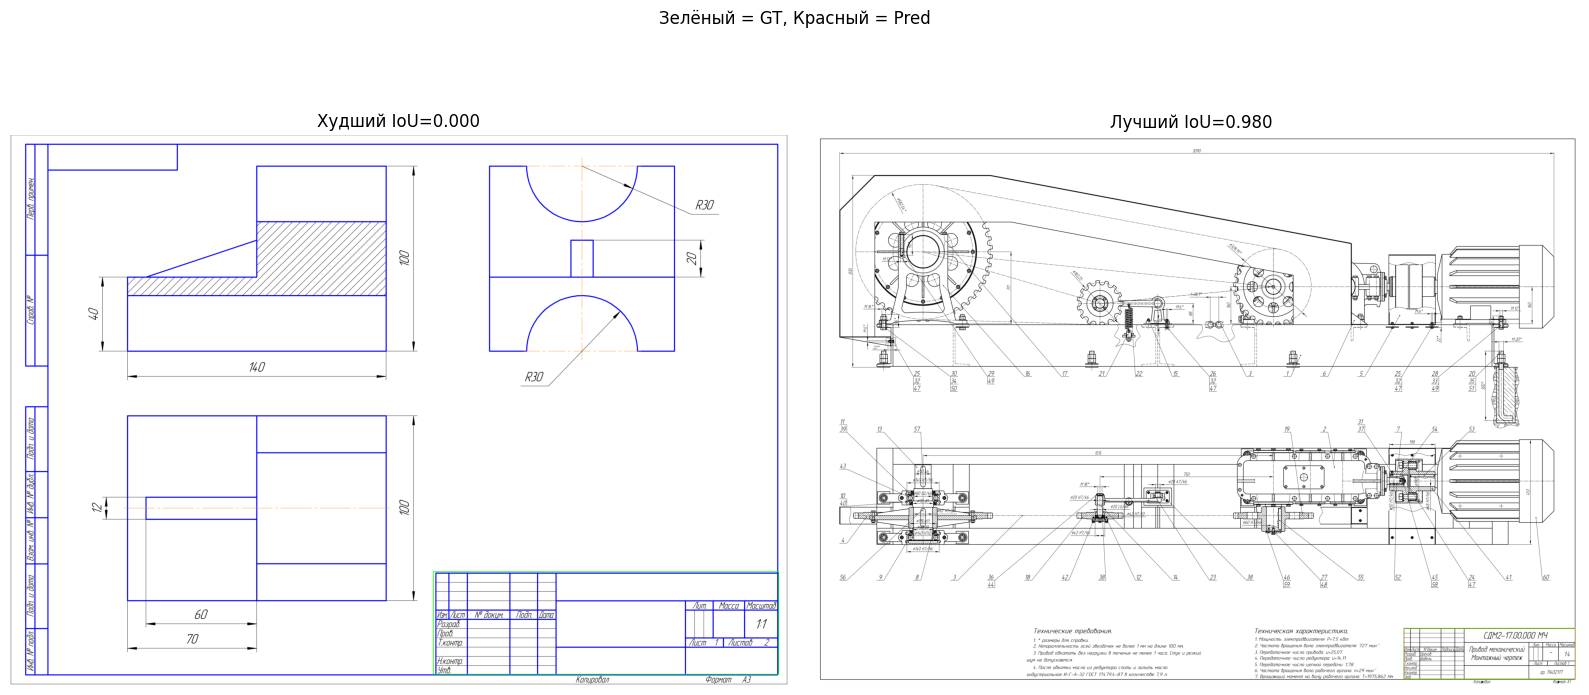

In [5]:
# Сортируем по IoU
sorted_results = sorted(results, key=lambda r: r['iou'])

worst = sorted_results[0]
best = sorted_results[-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax_idx, (result, title_prefix) in enumerate([(worst, 'Худший'), (best, 'Лучший')]):
    img_path = [p for p in all_images if p.name == result['image']][0]
    img, _ = load_image_and_labels(img_path, LABEL_DIR)
    
    vis = img.copy()
    
    if result['gt']:
        x, y, w, h = result['gt']
        cv2.rectangle(vis, (x, y), (x+w, y+h), (0, 255, 0), 3)
    
    if result['pred']:
        x, y, w, h = result['pred']
        cv2.rectangle(vis, (x, y), (x+w, y+h), (0, 0, 255), 2)
    
    axes[ax_idx].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    axes[ax_idx].set_title(f'{title_prefix} IoU={result["iou"]:.3f}')
    axes[ax_idx].axis('off')

plt.suptitle('Зелёный = GT, Красный = Pred')
plt.tight_layout()
plt.show()

## Выводы

**Метрики CV Baseline (contour detection):**
- Detection rate: 24/49 (49.0%)
- IoU mean: 0.330
- IoU median: 0.000
- IoU > 0.5: 17/49 (34.7%)

**Выводы:**
- Contour-based подход находит только 49% штампов — слабая базовая линия
- Median IoU = 0.0 означает, что >50% детекций не пересекаются с GT
- Эвристика с aspect ratio 3.55 слишком грубая для разнообразия реальных чертежей
- Метод хорошо работает на чистых чертежах, но fails на сложных фонах

**Следующие шаги:**
- Запустить YOLO baseline (exp04) — ожидаем IoU > 0.5
- Обучить Faster R-CNN (exp05) для сравнения
- Скомбинировать лучший CNN с CV refine в hybrid (exp06)
